<a href="https://colab.research.google.com/github/crowell97/ES5201/blob/main/ES5201_Lecture15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Amplitude, Phase and the Propagator Matrix — A Companion Notebook

**EARTH 5201 — Introduction to Seismology**

**The Ohio State University**

**Companion notebook to Lecture 15 — Ray Theory: Amplitude and Phase**

This notebook implements the three main quantitative threads from lecture:

1. **SH reflection/transmission coefficients past the critical angle** — tracking their complex values and phase, and confirming energy-normalized flux conservation.
2. **The turning-point limit** — showing numerically that $R_{SH}\to -i$ exactly as the layer spacing shrinks to zero, the exact $\pi/2$ phase advance that identifies a Hilbert transform.
3. **A toy propagator-matrix stack** — building the SH layer matrices $\mathbf F$ and propagator matrix $\mathbf P$ for a multi-layer system, and checking that the matrix approach reproduces the direct two-layer boundary-condition result.

## 0. Setup

In [1]:
import numpy as np
import matplotlib.pylab as plt

plt.rcParams["figure.figsize"] = (8, 6)

## Part 1 — SH Reflection/Transmission Past the Critical Angle

Normalized to unit incident amplitude, the SH coefficients are

$$R_{SH} = \frac{\rho_1\beta_1\cos\theta_1 - \rho_2\beta_2\cos\theta_2}{\rho_1\beta_1\cos\theta_1 + \rho_2\beta_2\cos\theta_2}, \qquad T_{SH} = \frac{2\rho_1\beta_1\cos\theta_1}{\rho_1\beta_1\cos\theta_1 + \rho_2\beta_2\cos\theta_2},$$

with $\theta_2$ tied to $\theta_1$ by Snell's law, $\sin\theta_1/\beta_1 = \sin\theta_2/\beta_2$. When $\beta_2 > \beta_1$, there is a critical angle $\theta_c = \arcsin(\beta_1/\beta_2)$ beyond which $\cos\theta_2$ — and hence $R_{SH}$, $T_{SH}$ — become complex.

In [2]:
def R_T_SH(theta1_deg, rho1, beta1, rho2, beta2):
    """SH reflection/transmission coefficients (complex-valued past the
    critical angle) as a function of incidence angle in degrees."""
    theta1 = np.radians(theta1_deg)
    p = np.sin(theta1) / beta1
    sin_theta2 = p * beta2
    cos_theta2 = np.sqrt(1 - sin_theta2**2 + 0j)   # +0j keeps this complex past critical
    num_R = rho1 * beta1 * np.cos(theta1) - rho2 * beta2 * cos_theta2
    num_T = 2 * rho1 * beta1 * np.cos(theta1)
    den = rho1 * beta1 * np.cos(theta1) + rho2 * beta2 * cos_theta2
    return num_R / den, num_T / den

rho1, beta1 = 2.7, 3.2    # Mg/m^3, km/s
rho2, beta2 = 2.9, 4.5    # faster, denser layer below -> critical angle exists
theta_c = np.degrees(np.arcsin(beta1 / beta2))
print(f"Critical angle: {theta_c:.2f} degrees")

theta1_deg = np.linspace(0.01, 89.9, 900)
R, T = R_T_SH(theta1_deg, rho1, beta1, rho2, beta2)

Critical angle: 45.33 degrees


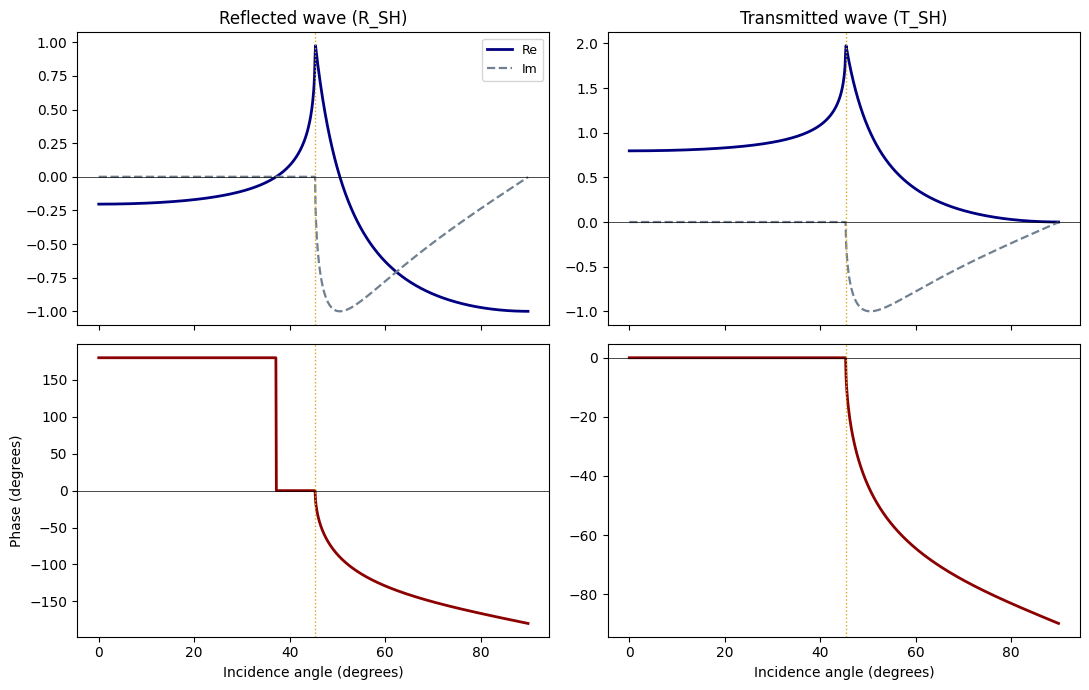

|R_SH| at 80 deg (postcritical): 1.0000  (total internal reflection -> magnitude 1)


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)

axes[0, 0].plot(theta1_deg, R.real, color="navy", lw=2, label="Re")
axes[0, 0].plot(theta1_deg, R.imag, "--", color="slategray", lw=1.6, label="Im")
axes[0, 0].axvline(theta_c, color="goldenrod", lw=1, ls=":")
axes[0, 0].set_title("Reflected wave (R_SH)")
axes[0, 0].legend(fontsize=9)

axes[0, 1].plot(theta1_deg, T.real, color="navy", lw=2)
axes[0, 1].plot(theta1_deg, T.imag, "--", color="slategray", lw=1.6)
axes[0, 1].axvline(theta_c, color="goldenrod", lw=1, ls=":")
axes[0, 1].set_title("Transmitted wave (T_SH)")

axes[1, 0].plot(theta1_deg, np.degrees(np.angle(R)), color="darkred", lw=2)
axes[1, 0].axvline(theta_c, color="goldenrod", lw=1, ls=":")
axes[1, 0].set_ylabel("Phase (degrees)")
axes[1, 0].set_xlabel("Incidence angle (degrees)")

axes[1, 1].plot(theta1_deg, np.degrees(np.angle(T)), color="darkred", lw=2)
axes[1, 1].axvline(theta_c, color="goldenrod", lw=1, ls=":")
axes[1, 1].set_xlabel("Incidence angle (degrees)")

for ax in axes.flat:
    ax.axhline(0, color="black", lw=0.5)
plt.tight_layout()
plt.show()

print(f"|R_SH| at 80 deg (postcritical): {abs(R[np.argmin(np.abs(theta1_deg-80))]):.4f}  (total internal reflection -> magnitude 1)")

Past the critical angle, $|R_{SH}| = 1$ to numerical precision: no energy is transmitted downward, and all of it is carried by the reflected wave as a pure phase shift — total internal reflection.

### Energy-flux check

The energy-normalized coefficients should satisfy $\mathcal R + \mathcal T = 1$ below the critical angle (both waves propagate and carry real energy flux), and $\mathcal R = 1$, with $T_{SH}$ complex but carrying no net flux, above it.

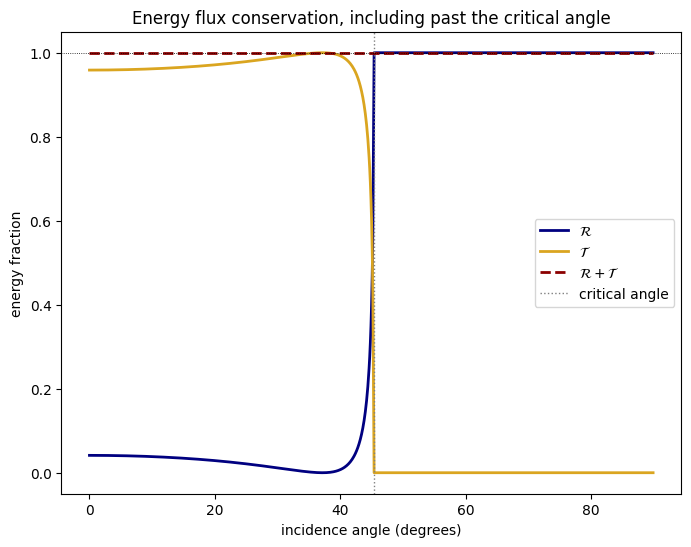

Max |R+T-1| below critical: 6.661338147750939e-16
Max |R-1| above critical (total internal reflection): 8.881784197001252e-16


In [4]:
def energy_RT_SH(theta1_deg, rho1, beta1, rho2, beta2):
    theta1 = np.radians(theta1_deg)
    R, T = R_T_SH(theta1_deg, rho1, beta1, rho2, beta2)
    p = np.sin(theta1) / beta1
    sin_theta2 = p * beta2
    propagating = sin_theta2 <= 1.0
    cos_theta2 = np.sqrt(np.clip(1 - sin_theta2**2, 0, None))
    energy_R = np.abs(R) ** 2
    energy_T = np.where(
        propagating,
        (rho2 * beta2 * cos_theta2) / (rho1 * beta1 * np.cos(theta1)) * np.abs(T) ** 2,
        0.0,  # the transmitted wave below the interface carries no real energy flux past critical
    )
    return energy_R, energy_T

energy_R, energy_T = energy_RT_SH(theta1_deg, rho1, beta1, rho2, beta2)
total = energy_R + energy_T

plt.plot(theta1_deg, energy_R, color="navy", lw=2, label=r"$\mathcal{R}$")
plt.plot(theta1_deg, energy_T, color="goldenrod", lw=2, label=r"$\mathcal{T}$")
plt.plot(theta1_deg, total, "--", color="darkred", lw=2, label=r"$\mathcal{R}+\mathcal{T}$")
plt.axvline(theta_c, color="gray", lw=1, ls=":", label="critical angle")
plt.axhline(1.0, color="black", lw=0.6, ls=":")
plt.xlabel("incidence angle (degrees)")
plt.ylabel("energy fraction")
plt.legend()
plt.title("Energy flux conservation, including past the critical angle")
plt.show()

below = theta1_deg < theta_c - 1
above = theta1_deg > theta_c + 1
print("Max |R+T-1| below critical:", np.max(np.abs(total[below] - 1.0)))
print("Max |R-1| above critical (total internal reflection):", np.max(np.abs(energy_R[above] - 1.0)))

## Part 2 — The Turning-Point Limit: R_SH → −i

At a true interface, $R_{SH}$ is a smooth function of the impedance contrast. But at a *turning point* in a continuously varying medium, the "interface" is the limit of a vanishingly small velocity jump $d\beta$ straddling the depth where the horizontal slowness $p$ exactly equals the local slowness $1/\beta$. Lecture showed that in this limit, with $\beta^\mp=\beta\mp d\beta$, $\rho^\mp=\rho\mp d\rho$,

$$R_{SH} = \frac{\rho^-\beta^-\sqrt{1-\beta^{-2}(\beta-d\beta)^2} - \rho^+\beta^+\sqrt{1-\beta^{-2}(\beta+d\beta)^2}}{\rho^-\beta^-\sqrt{1-\beta^{-2}(\beta-d\beta)^2} + \rho^+\beta^+\sqrt{1-\beta^{-2}(\beta+d\beta)^2}} \ \longrightarrow\ -i \quad \text{as } d\beta\to 0.$$

We check this numerically by shrinking $d\beta$ toward zero and watching $R_{SH}$ converge to $-i$.

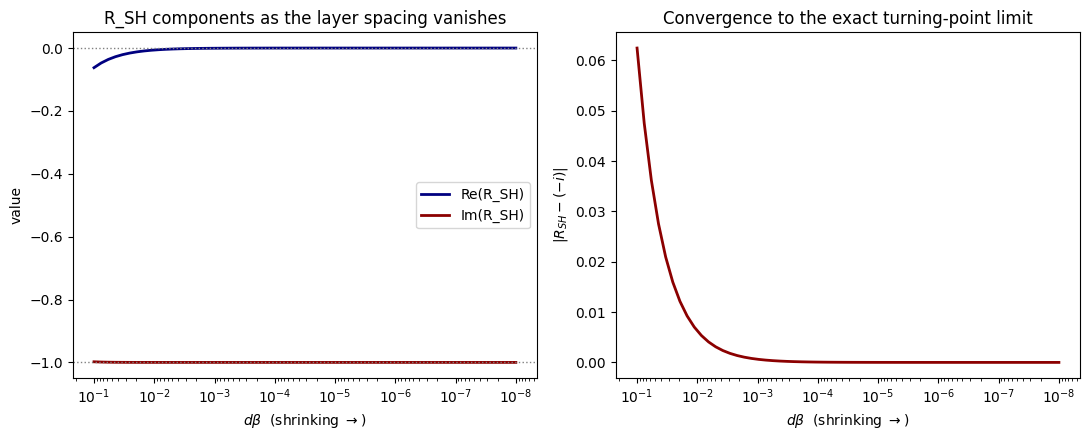

R_SH at d_beta=1.0e-08: -0.000000-1.000000j
Distance from -i: 5.00e-09


In [5]:
def sh_turning_point_R(beta, d_beta, rho=3.0, d_rho=0.0):
    """SH reflection coefficient across a thin velocity/density jump straddling
    a turning point, following the lecture's thin-layer construction exactly."""
    beta_minus, beta_plus = beta - d_beta, beta + d_beta
    rho_minus, rho_plus = rho - d_rho, rho + d_rho

    term_minus = np.sqrt((1 - (beta_minus / beta) ** 2) + 0j)
    term_plus = np.sqrt((1 - (beta_plus / beta) ** 2) + 0j)

    num = rho_minus * beta_minus * term_minus - rho_plus * beta_plus * term_plus
    den = rho_minus * beta_minus * term_minus + rho_plus * beta_plus * term_plus
    return num / den

beta0 = 4.0
d_betas = np.logspace(-1, -8, 60)
R_turning = np.array([sh_turning_point_R(beta0, db) for db in d_betas])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].semilogx(d_betas, R_turning.real, color="navy", lw=2, label="Re(R_SH)")
axes[0].semilogx(d_betas, R_turning.imag, color="darkred", lw=2, label="Im(R_SH)")
axes[0].axhline(-1, color="gray", lw=1, ls=":")
axes[0].axhline(0, color="gray", lw=1, ls=":")
axes[0].invert_xaxis()
axes[0].set_xlabel(r"$d\beta$  (shrinking $\rightarrow$)")
axes[0].set_ylabel("value")
axes[0].set_title("R_SH components as the layer spacing vanishes")
axes[0].legend()

axes[1].semilogx(d_betas, np.abs(R_turning - (-1j)), color="darkred", lw=2)
axes[1].invert_xaxis()
axes[1].set_xlabel(r"$d\beta$  (shrinking $\rightarrow$)")
axes[1].set_ylabel(r"$|R_{SH} - (-i)|$")
axes[1].set_title("Convergence to the exact turning-point limit")
plt.tight_layout()
plt.show()

print(f"R_SH at d_beta={d_betas[-1]:.1e}: {R_turning[-1]:.6f}")
print(f"Distance from -i: {abs(R_turning[-1] - (-1j)):.2e}")

As $d\beta \to 0$, $R_{SH} \to -i$ to many digits of precision — exactly the $\pi/2$ phase advance identified in lecture. The upgoing wave at a turning point is the **Hilbert transform** of the downgoing wave, with its pulse shape altered accordingly — a direct consequence of rays folding back on themselves at an internal caustic.

## Part 3 — A Toy Propagator-Matrix Stack

For a stack of homogeneous SH layers, the stress-displacement vector propagates between depths via the propagator matrix

$$\mathbf f(z_2) = \mathbf P(z_1, z_2)\, \mathbf f(z_1), \qquad \mathbf P(z_1,z_2) = \mathbf E\begin{bmatrix}e^{i\omega\eta(z_2-z_1)} & 0 \\ 0 & e^{-i\omega\eta(z_2-z_1)}\end{bmatrix}\mathbf E^{-1}.$$

We build this directly for a 3-layer SH system and compare the resulting *effective* top-surface reflection coefficient against stacking the boundary-condition matrices layer by layer — a minimal, from-scratch version of the Haskell/propagator-matrix machinery from lecture.

In [6]:
def layer_matrix_F(mu, eta, omega, z=0.0):
    """F(z) for one homogeneous SH layer, as in lecture: f(z) = F(z) w."""
    e_pos = np.exp(1j * omega * eta * z)
    e_neg = np.exp(-1j * omega * eta * z)
    return np.array([
        [e_pos, e_neg],
        [1j * omega * mu * eta * e_pos, -1j * omega * mu * eta * e_neg],
    ], dtype=complex)

def eta_of(beta, p):
    u = 1.0 / beta
    return np.sqrt(u**2 - p**2 + 0j)

def stack_reflection_coefficient(betas, rhos, thicknesses, p, omega=1.0):
    """Effective SH reflection coefficient seen from the top of a stack of
    layers over a welded half-space, built by chaining layer matrices
    F_i^{-1} F_{i+1} boundary-condition matches, exactly as in lecture.

    Continuity of f(z) across interface i/(i+1) gives
        F_i(thickness_i) w_i = F_{i+1}(0) w_{i+1}
        =>  w_i = M_i w_{i+1},   M_i = F_i(thickness_i)^{-1} F_{i+1}(0).
    Chaining top to bottom:
        w_1 = M_1 M_2 ... M_{n-1} w_n = M_total w_n.
    With w_1 = [1, R]^T (unit incident, unknown reflection) and w_n = [T, 0]^T
    (only a downgoing wave surviving into the half-space), solve for R, T.
    """
    n = len(betas)
    mus = rhos * betas**2
    etas = np.array([eta_of(b, p) for b in betas])

    M_total = np.eye(2, dtype=complex)
    for i in range(n - 1):
        F_i = layer_matrix_F(mus[i], etas[i], omega, z=thicknesses[i])
        F_ip1 = layer_matrix_F(mus[i + 1], etas[i + 1], omega, z=0.0)
        M_i = np.linalg.inv(F_i) @ F_ip1
        M_total = M_total @ M_i          # left-to-right: M_1 @ M_2 @ ... @ M_{n-1}

    T = 1.0 / M_total[0, 0]
    R = M_total[1, 0] * T
    return R

# Two-layer sanity check: compare the propagator-matrix result to the direct
# boundary-condition formula R_SH from Part 1. With only one interface, we put
# the z=0 reference for each layer right at that interface (thickness 0): the
# incident/reflected amplitudes in a semi-infinite top layer don't depend on
# where "z=0" sits within that layer, so this is the natural, zero-phase choice.
betas2 = np.array([3.2, 4.5])
rhos2 = np.array([2.7, 2.9])
thick2 = np.array([0.0])  # reference depth = the interface itself

theta1_test = 20.0
p_test = np.sin(np.radians(theta1_test)) / betas2[0]

R_direct, _ = R_T_SH(np.array([theta1_test]), rhos2[0], betas2[0], rhos2[1], betas2[1])
R_matrix = stack_reflection_coefficient(betas2, rhos2, thick2, p_test)

print(f"Direct boundary-condition R_SH:   {R_direct[0]:.6f}")
print(f"Propagator-matrix R_SH:           {R_matrix:.6f}")
print(f"Difference:                       {abs(R_direct[0] - R_matrix):.2e}")

Direct boundary-condition R_SH:   -0.169859+0.000000j
Propagator-matrix R_SH:           -0.169859+0.000000j
Difference:                       5.55e-17


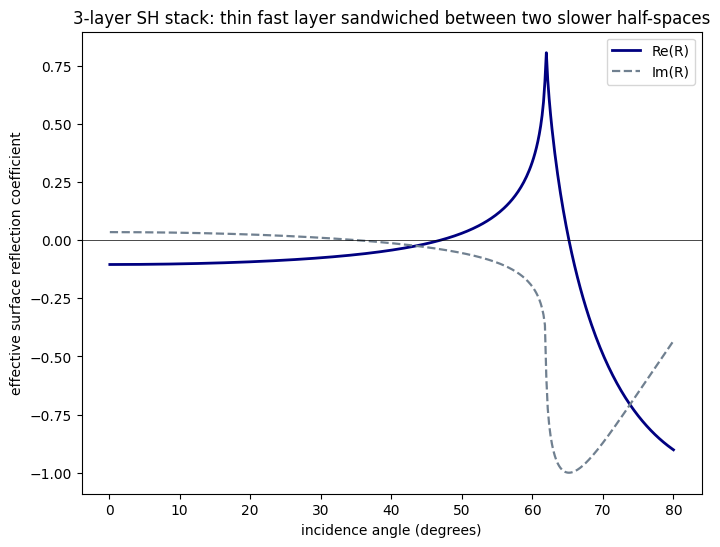

Max |R| over all angles (should stay <= 1, extra peaks from the internal thin layer): 1.0000000000000002


In [7]:
# A genuine 3-layer stack: a thin high-velocity layer sandwiched between two
# slower half-spaces -- something the direct two-layer formula cannot handle,
# but the propagator-matrix chain handles exactly as easily as two layers.
# Layer 1 is the semi-infinite top half-space, so its "thickness" is just the
# (arbitrary, zero-phase) reference depth; layer 2 is the real, finite layer
# whose thickness actually matters; layer 3 is the bottom half-space.
betas3 = np.array([3.0, 4.2, 3.4])
rhos3 = np.array([2.6, 2.9, 2.8])
thick3 = np.array([0.0, 0.6])   # layer-1 reference depth (0), then layer-2's real thickness

theta1_deg_stack = np.linspace(0.1, 80, 400)
R_stack = np.array([
    stack_reflection_coefficient(betas3, rhos3, thick3,
                                  np.sin(np.radians(th)) / betas3[0])
    for th in theta1_deg_stack
])

plt.plot(theta1_deg_stack, R_stack.real, color="navy", lw=2, label="Re(R)")
plt.plot(theta1_deg_stack, R_stack.imag, "--", color="slategray", lw=1.6, label="Im(R)")
plt.axhline(0, color="black", lw=0.5)
plt.xlabel("incidence angle (degrees)")
plt.ylabel("effective surface reflection coefficient")
plt.title("3-layer SH stack: thin fast layer sandwiched between two slower half-spaces")
plt.legend()
plt.show()

print("Max |R| over all angles (should stay <= 1, extra peaks from the internal thin layer):",
      np.max(np.abs(R_stack)))

The thin fast layer produces extra resonance-like structure in the effective reflection coefficient as a function of angle — interference between the multiple internal reflections the layer traps — exactly the complication flagged in lecture: once a stack has more than one interface, the final amplitudes are no longer a single clean formula, even though the propagator-matrix bookkeeping makes setting up the system completely mechanical.

## Summary & Further Resources

- **Past the critical angle**, SH reflection/transmission coefficients go complex; $|R_{SH}|\to 1$ (total internal reflection) while $T_{SH}$ carries no net energy flux, just a phase-shifted, non-propagating signal.
- **At a turning point**, the reflection coefficient converges to exactly $-i$: a clean $\pi/2$ phase advance, confirming that turning-ray amplitudes are the Hilbert transform of the downgoing wave.
- **Propagator matrices** reproduce the direct two-layer boundary-condition result exactly, and extend immediately to multi-layer stacks where no simple closed-form reflection coefficient exists — at the cost of needing to solve a linear system for the amplitudes.
- **Next steps** — the same machinery extends to P-SV (4×4 matrices instead of 2×2), and underlies full reflectivity/Haskell-Thomson methods for computing synthetic seismograms in layered media.